# 01 — Data Exploration: CRMLS Sold Listings (California)

**Project:** California Property Close Price Prediction (IDX Exchange Data Science Internship)
**Week 2 deliverable:** basic EDA of the target (`ClosePrice`) and core physical features (`LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger`, lot size).

**Scope rules (from the task prompt):**
- Source files: `CRMLSSold*.csv` (local copies of `/raw/California` on the IDX FTP; raw files are never modified).
- Only `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`.
- Minimum six months of data. This notebook loads **every sold month available locally (January 2024 – April 2026, 28 months)** so that the Week 3 training-window experiment (choosing X months) has the full history to work with.

**What this notebook does not do:** it does not drop, impute, or transform anything permanently. Cleaning decisions are flagged here and made in `02_preprocessing.ipynb`.

## 1. Setup

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Data folder: works whether the notebook is run from the repo root or from notebooks/
DATA_DIR = next(p for p in [Path("csv"), Path("../csv")] if p.exists())
FIG_DIR = DATA_DIR.parent / "figures" / "01_exploration"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot style: one primary hue, recessive grid
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#d0cfca", "grid.color": "#ecebe7",
                                     "axes.titleweight": "bold", "figure.dpi": 110})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=130)

dollars = mtick.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M" if abs(v) >= 1e6 else f"${v/1e3:.0f}K")
print("Data folder:", DATA_DIR.resolve())

Data folder: /sessions/rcw-01fmtnzuj2kadkprv5ehodd4/mnt/IDX Exchange/csv


## 2. Load all sold files and filter to single-family residences

Each monthly file is read in full so that the raw row counts and the per-column missingness can be logged. Only the single-family residential rows are kept in memory, along with the columns that matter for exploration and modelling (agent names, e-mails, and office fields are dropped here to save memory; they are excluded from the model anyway).

Schema note: the files are not identical. The `_filled` files (2024-01, 03–07, 2025-01) carry two extra columns, `latfilled` / `lonfilled`; 2024-08 onward adds `BuyerAgentAOR` / `ListAgentAOR`; 2026-02 onward adds `OriginatingSystemName` / `OriginatingSystemSubName`; the early-2024 files carry `BuyerAgencyCompensation` fields. `pd.concat` aligns these by name.

In [2]:
KEEP = [
    # identifiers / location
    "ListingKey", "ListingId", "UnparsedAddress", "City", "PostalCode", "CountyOrParish", "MLSAreaMajor",
    "Latitude", "Longitude", "latfilled", "lonfilled", "HighSchoolDistrict", "SubdivisionName",
    # type / status
    "PropertyType", "PropertySubType", "MlsStatus", "NewConstructionYN",
    # target and dates
    "ClosePrice", "CloseDate", "PurchaseContractDate", "ListingContractDate",
    # leakage fields (kept only to demonstrate why they are excluded)
    "ListPrice", "OriginalListPrice", "DaysOnMarket",
    # physical characteristics
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "LotSizeAcres", "LotSizeArea",
    "YearBuilt", "Stories", "Levels", "GarageSpaces", "ParkingTotal", "MainLevelBedrooms",
    "PoolPrivateYN", "ViewYN", "FireplaceYN", "AttachedGarageYN", "AssociationFee",
]

files = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
inventory, frames, null_counts, n_sfr_total = [], [], None, 0

for f in files:
    month = re.search(r"(\d{6})", f.name).group(1)
    raw = pd.read_csv(f, low_memory=False)
    is_sfr = (raw["PropertyType"] == "Residential") & (raw["PropertySubType"] == "SingleFamilyResidence")
    sfr = raw.loc[is_sfr]
    inventory.append({"month": month, "file": f.name, "columns": raw.shape[1], "rows_raw": len(raw),
                      "rows_residential": int((raw["PropertyType"] == "Residential").sum()),
                      "rows_sfr": int(is_sfr.sum())})
    # missingness across ALL columns, on the SFR subset
    nc = sfr.isna().sum().reindex(sorted(set(raw.columns)), fill_value=0)
    present = pd.Series(len(sfr), index=nc.index)
    null_counts = pd.DataFrame({"nulls": nc, "rows": present}) if null_counts is None else \
        null_counts.add(pd.DataFrame({"nulls": nc, "rows": present}), fill_value=0)
    n_sfr_total += len(sfr)
    frames.append(sfr[[c for c in KEEP if c in sfr.columns]].assign(source_month=month))

df = pd.concat(frames, ignore_index=True)
inventory = pd.DataFrame(inventory)
print(f"{len(files)} files | {inventory.rows_raw.sum():,} raw rows | {len(df):,} single-family residential rows "
      f"({len(df)/inventory.rows_raw.sum():.1%} of all sold records)")
print(f"In-memory size: {df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
inventory

28 files | 615,707 raw rows | 309,735 single-family residential rows (50.3% of all sold records)


In-memory size: 444 MB


,month,file,columns,rows_raw,rows_residential,rows_sfr
0,202401,CRMLSSold202401_filled.csv,80,17958,11194,8322
1,202402,CRMLSSold202402.csv,78,19925,13063,9564
2,202403,CRMLSSold202403_filled.csv,80,23276,15784,11634
3,202404,CRMLSSold202404_filled.csv,80,24640,17295,12745
4,202405,CRMLSSold202405_filled.csv,80,26487,18474,13831
5,202406,CRMLSSold202406_filled.csv,80,24328,16625,12545
6,202407,CRMLSSold202407_filled.csv,80,26240,17809,13378
7,202408,CRMLSSold202408.csv,78,24558,16791,12433
8,202409,CRMLSSold202409.csv,78,21267,14555,10909
9,202410,CRMLSSold202410.csv,78,23274,16275,12347


### 2a. Type conversion

In [3]:
for c in ["CloseDate", "PurchaseContractDate", "ListingContractDate"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# Boolean flags arrive as the strings "True"/"False" (or real bools, or blank)
for c in ["PoolPrivateYN", "ViewYN", "FireplaceYN", "AttachedGarageYN", "NewConstructionYN", "latfilled", "lonfilled"]:
    df[c] = df[c].map({True: True, False: False, "True": True, "False": False})

df["PostalCode"] = df["PostalCode"].astype(str).str[:5]
df["close_month"] = df["CloseDate"].dt.to_period("M")

assert (df["close_month"].astype(str).str.replace("-", "") == df["source_month"]).all(), \
    "every row's CloseDate falls inside its file's month"
print("CloseDate range:", df.CloseDate.min().date(), "to", df.CloseDate.max().date())
print("MlsStatus values:", df.MlsStatus.unique())
df.dtypes.to_frame("dtype").T

CloseDate range: 2024-01-01 to 2026-04-30
MlsStatus values: ['Closed']


,ListingKey,ListingId,UnparsedAddress,City,PostalCode,CountyOrParish,MLSAreaMajor,Latitude,Longitude,latfilled,lonfilled,HighSchoolDistrict,SubdivisionName,PropertyType,PropertySubType,MlsStatus,NewConstructionYN,ClosePrice,CloseDate,PurchaseContractDate,ListingContractDate,ListPrice,OriginalListPrice,DaysOnMarket,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,LotSizeAcres,LotSizeArea,YearBuilt,Stories,Levels,GarageSpaces,ParkingTotal,MainLevelBedrooms,PoolPrivateYN,ViewYN,FireplaceYN,AttachedGarageYN,AssociationFee,source_month,close_month
dtype,int64,object,object,object,object,object,object,float64,float64,object,object,object,object,object,object,object,object,float64,datetime64[ns],datetime64[ns],datetime64[ns],float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,object,float64,float64,float64,object,object,object,object,float64,object,period[M]


## 3. Monthly volume and property-type mix

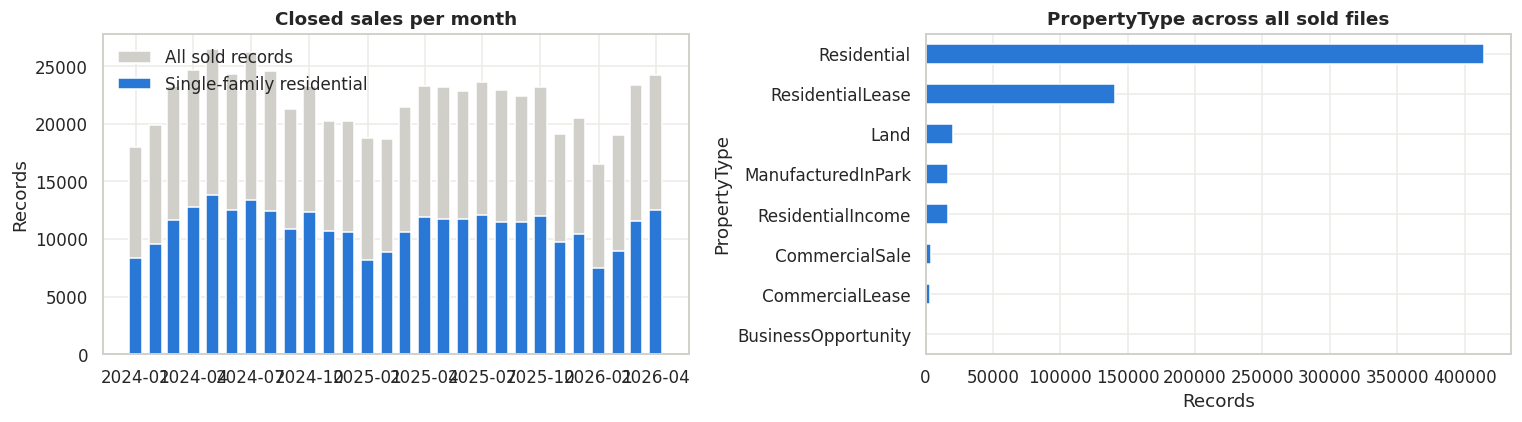

Single-family share of Residential: 74.8%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
inv = inventory.set_index(pd.to_datetime(inventory.month, format="%Y%m"))
ax[0].bar(inv.index, inv.rows_raw, width=20, color="#d0cfca", label="All sold records")
ax[0].bar(inv.index, inv.rows_sfr, width=20, color=BLUE, label="Single-family residential")
ax[0].set_title("Closed sales per month"); ax[0].legend(frameon=False); ax[0].set_ylabel("Records")

raw_types = pd.concat([pd.read_csv(f, usecols=["PropertyType"]) for f in files]).PropertyType.value_counts()
raw_types.sort_values().plot.barh(ax=ax[1], color=BLUE)
ax[1].set_title("PropertyType across all sold files"); ax[1].set_xlabel("Records")
plt.tight_layout(); save(fig, "monthly_volume_and_types"); plt.show()
print(f"Single-family share of Residential: {inventory.rows_sfr.sum()/inventory.rows_residential.sum():.1%}")

## 4. Missingness

Computed on the single-family subset, across **every** column in the raw files (not only the ones kept above). A column that is absent from some months counts as missing for those months.

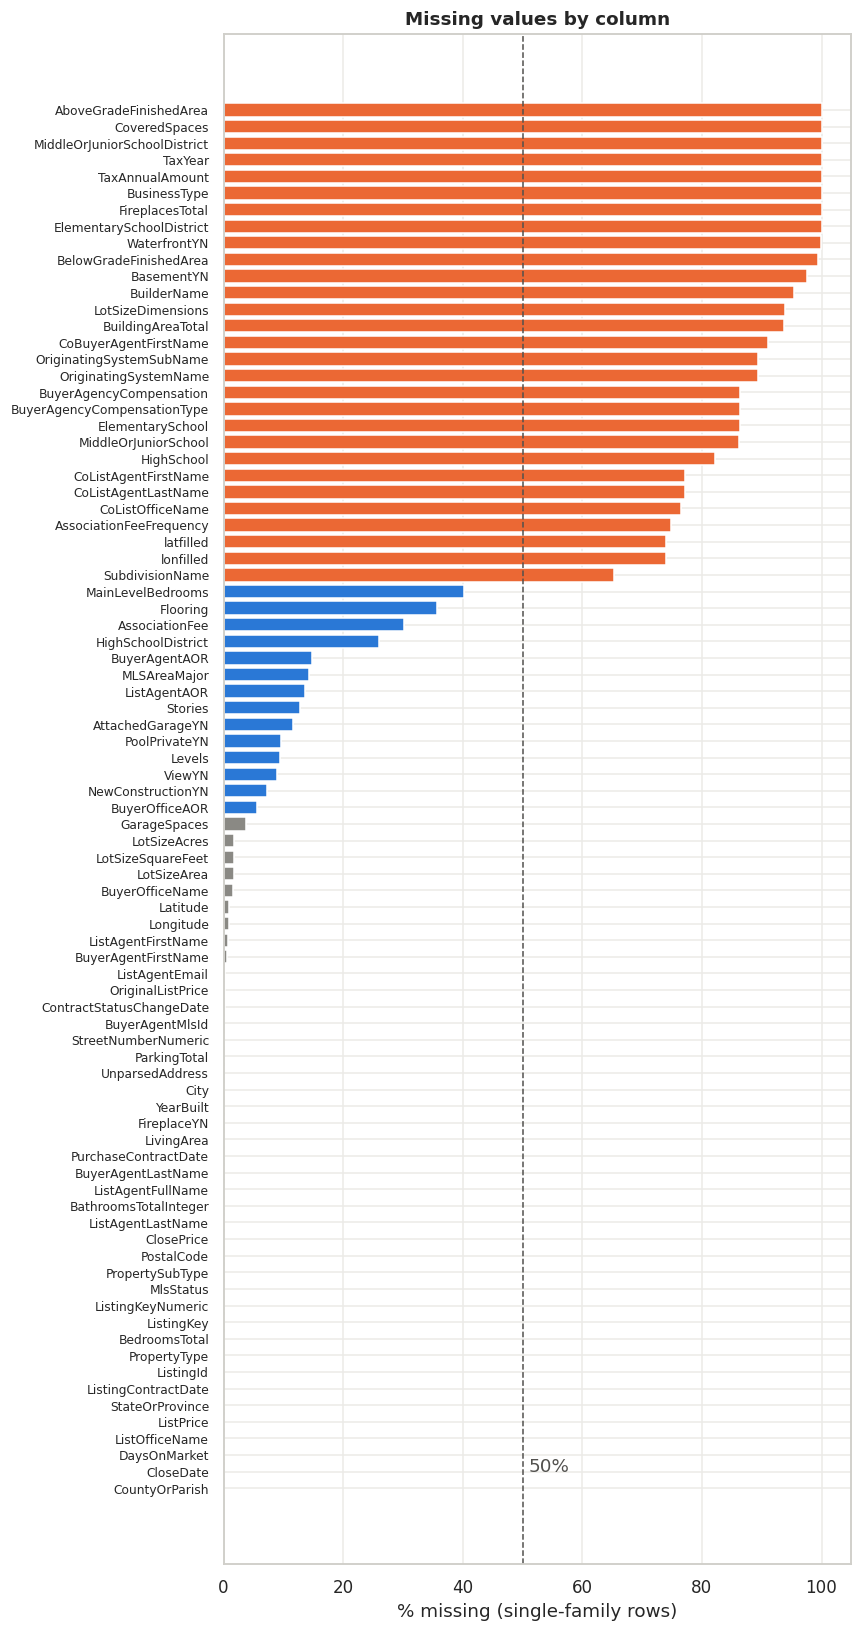

Columns 100% empty: ['WaterfrontYN', 'ElementarySchoolDistrict', 'FireplacesTotal', 'BusinessType', 'TaxAnnualAmount', 'TaxYear', 'MiddleOrJuniorSchoolDistrict', 'CoveredSpaces', 'AboveGradeFinishedArea']
Columns > 50% missing: ['SubdivisionName', 'lonfilled', 'latfilled', 'AssociationFeeFrequency', 'CoListOfficeName', 'CoListAgentLastName', 'CoListAgentFirstName', 'HighSchool', 'MiddleOrJuniorSchool', 'ElementarySchool', 'BuyerAgencyCompensationType', 'BuyerAgencyCompensation', 'OriginatingSystemName', 'OriginatingSystemSubName', 'CoBuyerAgentFirstName', 'BuildingAreaTotal', 'LotSizeDimensions', 'BuilderName', 'BasementYN', 'BelowGradeFinishedArea']


In [5]:
miss = (null_counts.nulls / n_sfr_total * 100).reindex(null_counts.index)
# columns absent from some files: add those rows as missing
absent_rows = n_sfr_total - null_counts.rows
miss = ((null_counts.nulls + absent_rows) / n_sfr_total * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 15))
colors = [GREY if v < 5 else (BLUE if v < 50 else ORANGE) for v in miss.values]
ax.barh(miss.index, miss.values, color=colors)
ax.axvline(50, color="#52514e", lw=1, ls="--"); ax.text(51, 1, "50%", color="#52514e")
ax.set_xlabel("% missing (single-family rows)"); ax.set_title("Missing values by column")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); save(fig, "missingness"); plt.show()

print("Columns 100% empty:", list(miss[miss >= 99.95].index))
print("Columns > 50% missing:", list(miss[(miss > 50) & (miss < 99.95)].index))

## 5. Target variable: `ClosePrice`

In [6]:
pcts = [0.001, 0.005, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995, 0.999]
desc = df["ClosePrice"].describe(percentiles=pcts)
print(f"Skewness: {df.ClosePrice.skew():.1f}   (log10 skewness: {np.log10(df.ClosePrice[df.ClosePrice > 0]).skew():.2f})")
print(f"ClosePrice <= 0: {(df.ClosePrice <= 0).sum()}   missing: {df.ClosePrice.isna().sum()}   "
      f"< $10K: {(df.ClosePrice < 1e4).sum()}   > $20M: {(df.ClosePrice > 2e7).sum()}")
desc.to_frame("ClosePrice").T

Skewness: 132.1   (log10 skewness: 0.48)
ClosePrice <= 0: 1   missing: 2   < $10K: 8   > $20M: 207


,count,mean,std,min,0.1%,0.5%,1%,5%,25%,50%,75%,95%,99%,99.5%,99.9%,max
ClosePrice,"309,733.00","1,297,553.12","5,643,292.57",0.00,"92,866.00","190,000.00","237,500.00","367,000.00","625,000.00","894,000.00","1,430,000.00","3,175,000.00","6,250,000.00","8,498,340.00","17,000,000.00","989,500,000.00"


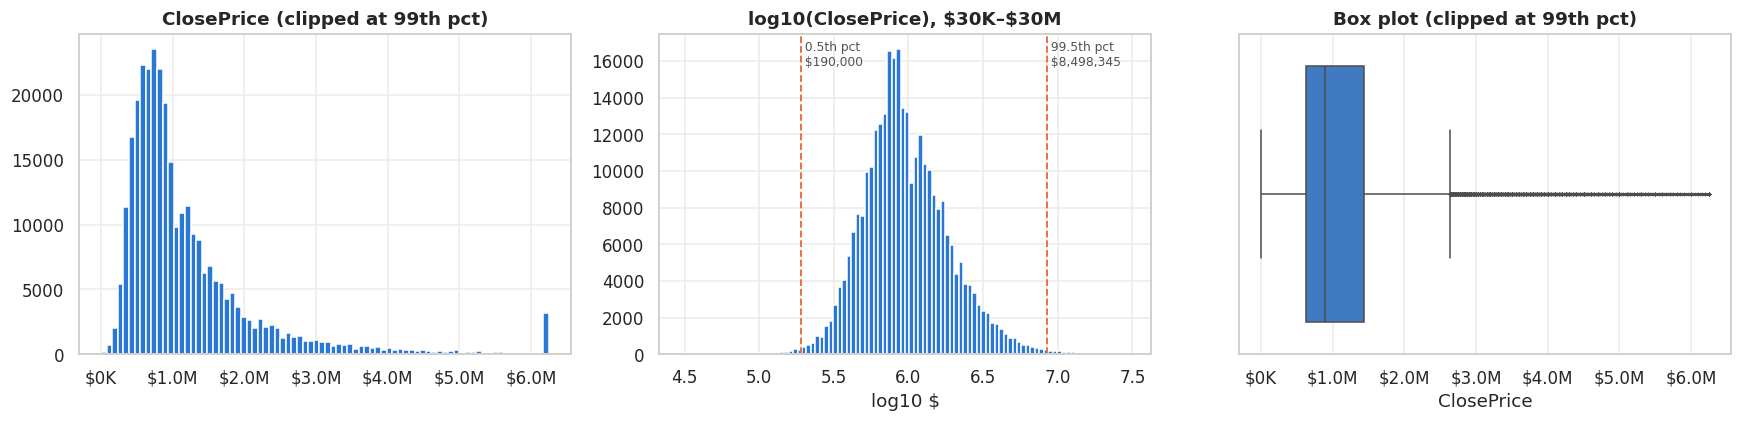

In [7]:
p = df.loc[df.ClosePrice > 0, "ClosePrice"]
lo, hi = p.quantile([0.005, 0.995])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(p.clip(upper=p.quantile(0.99)), bins=80, color=BLUE)
ax[0].set_title("ClosePrice (clipped at 99th pct)"); ax[0].xaxis.set_major_formatter(dollars)

ax[1].hist(np.log10(p[p.between(3e4, 3e7)]), bins=100, color=BLUE)
for v, lab in [(lo, "0.5th pct"), (hi, "99.5th pct")]:
    ax[1].axvline(np.log10(v), color=ORANGE, lw=1.2, ls="--")
    ax[1].text(np.log10(v), ax[1].get_ylim()[1]*0.9, f" {lab}\n ${v:,.0f}", color="#52514e", fontsize=8)
ax[1].set_title(r"log10(ClosePrice), \$30K–\$30M"); ax[1].set_xlabel("log10 $")

sns.boxplot(x=p.clip(upper=p.quantile(0.99)), ax=ax[2], color=BLUE, fliersize=1)
ax[2].set_title("Box plot (clipped at 99th pct)"); ax[2].xaxis.set_major_formatter(dollars)
plt.tight_layout(); save(fig, "closeprice_distribution"); plt.show()

The raw target is heavily right-skewed; on a log scale it is close to symmetric. This supports (a) modelling `log(ClosePrice)` or using tree models, and (b) using percentage metrics (MdAPE / MAPE) as the best-practices guide requires.

The 0.5th / 99.5th percentile lines shown here are **for illustration only**. Per the AVM best-practices document, the real outlier thresholds must be computed on the training months only (Week 3) and then frozen for the test month.

## 6. Core physical features

In [8]:
feat = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt"]
df[feat].describe(percentiles=[0.005, 0.01, 0.25, 0.5, 0.75, 0.99, 0.995]).T

,count,mean,std,min,0.5%,1%,25%,50%,75%,99%,99.5%,max
LivingArea,"309,569.00","2,033.88","1,058.30",0.00,638.00,728.00,"1,376.00","1,804.00","2,421.00","5,649.00","6,745.32","123,764.00"
BedroomsTotal,"309,735.00",3.48,0.96,0.00,1.00,2.00,3.00,3.00,4.00,6.00,6.00,45.00
BathroomsTotalInteger,"309,685.00",2.62,1.20,0.00,1.00,1.00,2.00,2.00,3.00,6.00,7.00,175.00
LotSizeSquareFeet,"304,408.00","266,665.18","14,602,826.47",0.00,"1,356.04","1,790.00","5,663.00","7,245.00","10,350.00","252,648.00","477,669.87","2,087,220,960.00"
YearBuilt,"309,510.00","1,975.63",27.50,"1,776.00","1,906.00","1,910.00","1,956.00","1,976.00","1,998.00","2,025.00","2,025.00","2,026.00"


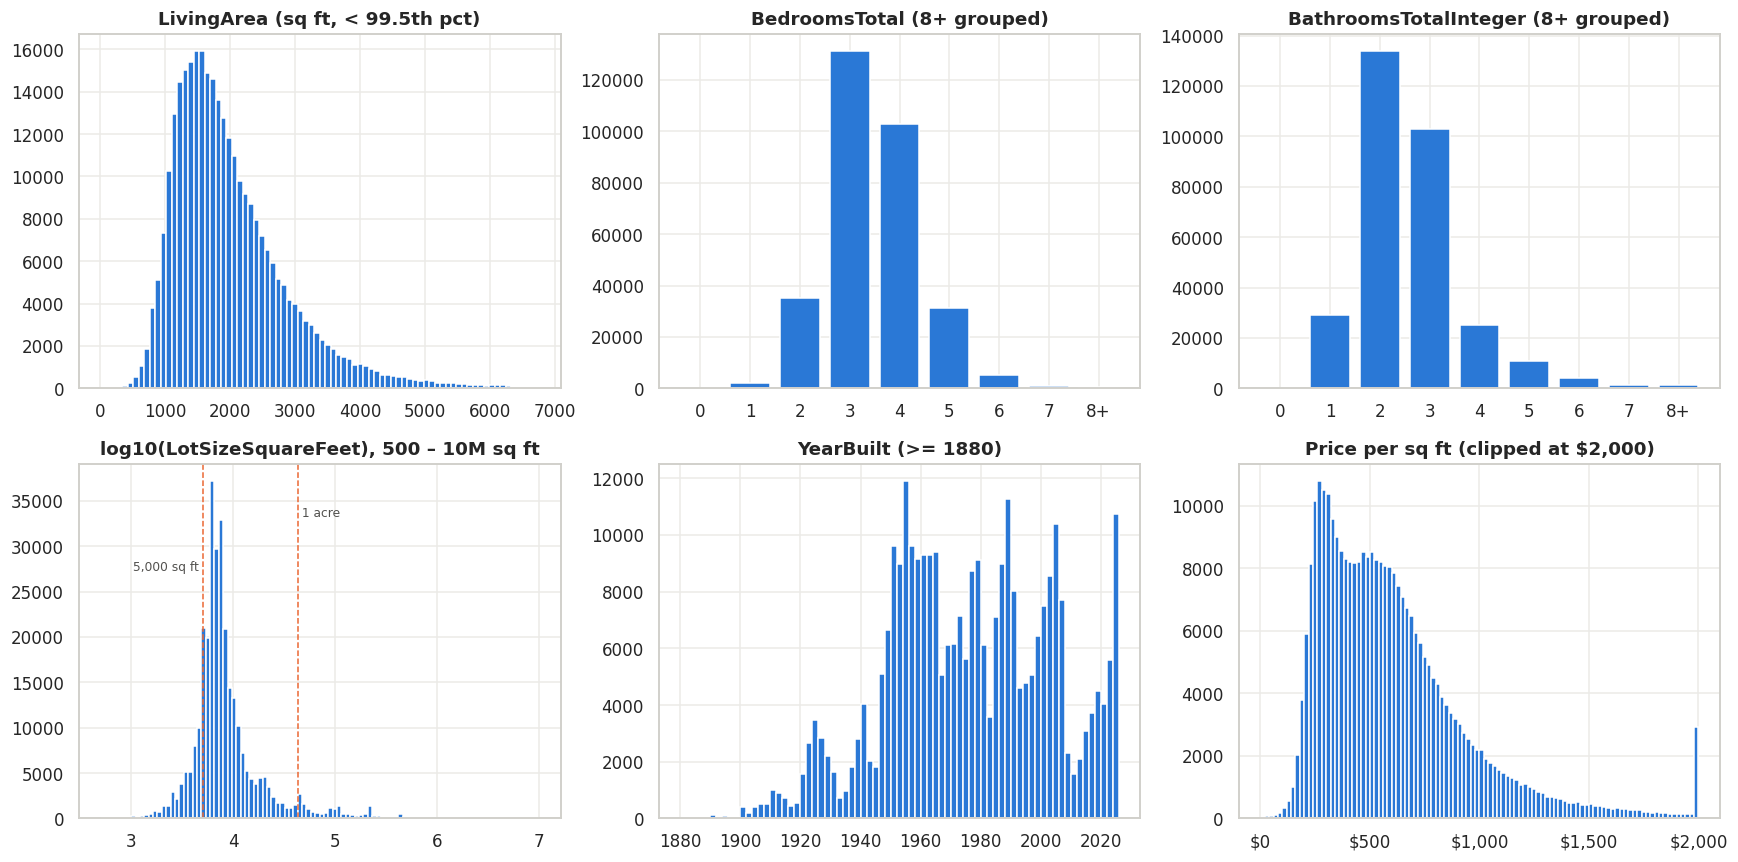

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
la = df.LivingArea.dropna()
ax[0, 0].hist(la[(la > 0) & (la < la.quantile(0.995))], bins=80, color=BLUE)
ax[0, 0].set_title("LivingArea (sq ft, < 99.5th pct)")

bd = df.BedroomsTotal.clip(upper=8).value_counts().sort_index()
ax[0, 1].bar(bd.index.astype(int).astype(str).str.replace("8", "8+"), bd.values, color=BLUE)
ax[0, 1].set_title("BedroomsTotal (8+ grouped)")

bt = df.BathroomsTotalInteger.clip(upper=8).value_counts().sort_index()
ax[0, 2].bar(bt.index.astype(int).astype(str).str.replace("8", "8+"), bt.values, color=BLUE)
ax[0, 2].set_title("BathroomsTotalInteger (8+ grouped)")

lot = df.LotSizeSquareFeet.dropna()
ax[1, 0].hist(np.log10(lot[lot.between(500, 1e7)]), bins=100, color=BLUE)
ax[1, 0].set_title("log10(LotSizeSquareFeet), 500 – 10M sq ft")
for v, lab, y in [(43560, "1 acre", 0.85), (5000, "5,000 sq ft ", 0.7)]:
    ax[1, 0].axvline(np.log10(v), color=ORANGE, ls="--", lw=1)
    ax[1, 0].text(np.log10(v), ax[1, 0].get_ylim()[1]*y, " " + lab, fontsize=8, color="#52514e", ha="left" if v > 10000 else "right")

yb = df.YearBuilt.dropna()
ax[1, 1].hist(yb[yb >= 1880], bins=range(1880, 2028, 2), color=BLUE)
ax[1, 1].set_title("YearBuilt (>= 1880)")

ax[1, 2].hist((df.ClosePrice / df.LivingArea).replace([np.inf], np.nan).dropna().clip(0, 2000), bins=100, color=BLUE)
ax[1, 2].set_title("Price per sq ft (clipped at $2,000)"); ax[1, 2].xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}")); ax[1, 2].xaxis.set_major_locator(mtick.MultipleLocator(500))
plt.tight_layout(); save(fig, "feature_distributions"); plt.show()

### 6a. Lot-size field consistency

There are three lot-size columns. The metadata says `LotSizeSquareFeet` and `LotSizeAcres` must be "in sync" with `LotSizeArea` + `LotSizeUnits`, but `LotSizeUnits` is not in the extract. The check below tests whether the fields actually agree.

In [10]:
lot = df[["LotSizeSquareFeet", "LotSizeAcres", "LotSizeArea"]].dropna()
lot = lot[(lot > 0).all(axis=1)]
ratio_sqft_acres = lot.LotSizeSquareFeet / (lot.LotSizeAcres * 43560)
consistent = ratio_sqft_acres.between(0.98, 1.02)
area_is_sqft = (lot.LotSizeArea / lot.LotSizeSquareFeet).between(0.98, 1.02)
area_is_acres = (lot.LotSizeArea / lot.LotSizeAcres).between(0.98, 1.02)
print(f"Rows with all three > 0: {len(lot):,}")
print(f"LotSizeSquareFeet == LotSizeAcres * 43,560 (within 2%): {consistent.mean():.1%}")
print(f"LotSizeArea appears to be in sq ft: {area_is_sqft.mean():.1%} | in acres: {area_is_acres.mean():.1%} | "
      f"neither: {(~area_is_sqft & ~area_is_acres).mean():.1%}")
print(f"Zero lot size: {(df.LotSizeSquareFeet == 0).sum():,}  | > 100 acres: {(df.LotSizeAcres > 100).sum():,}")

Rows with all three > 0: 303,929
LotSizeSquareFeet == LotSizeAcres * 43,560 (within 2%): 99.9%
LotSizeArea appears to be in sq ft: 97.1% | in acres: 2.9% | neither: 0.0%
Zero lot size: 162  | > 100 acres: 283


`LotSizeArea` mixes units (sometimes square feet, sometimes acres), so `LotSizeSquareFeet` is the lot-size field to carry forward.

## 7. Relationships with `ClosePrice`

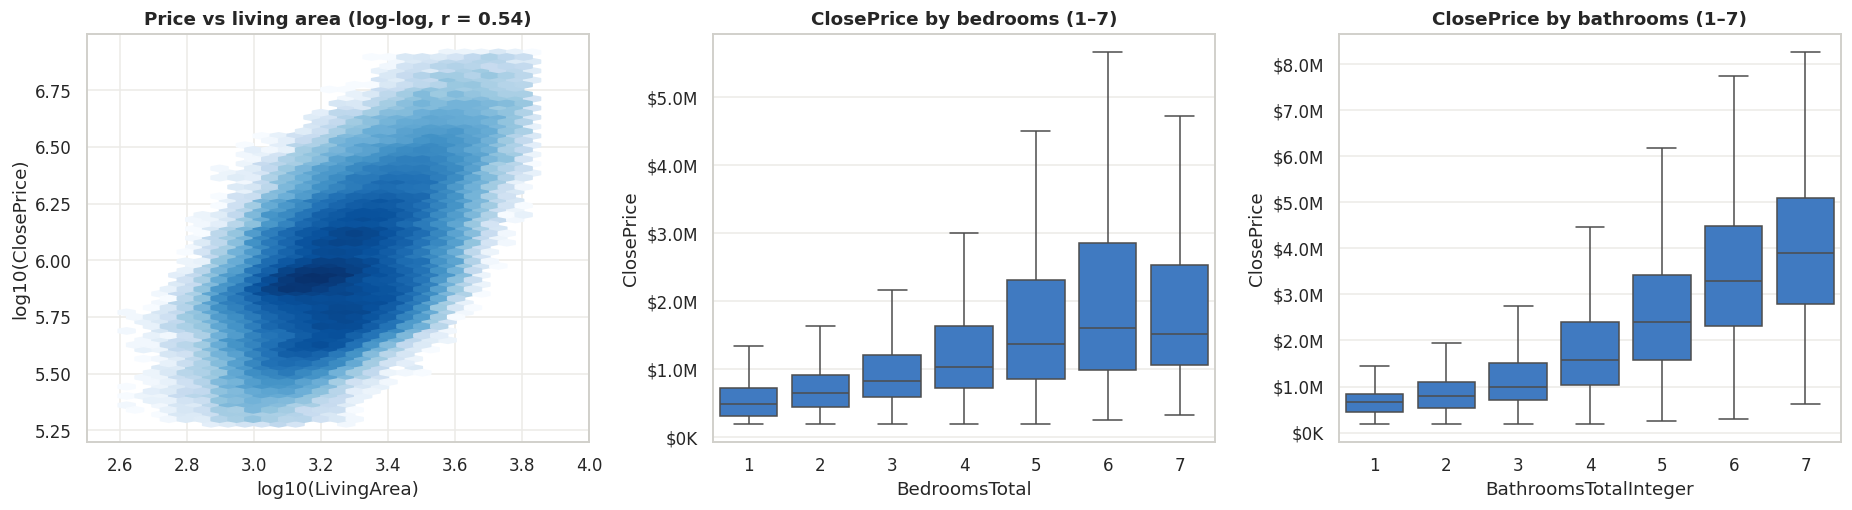

In [11]:
s = df[(df.ClosePrice > 0) & (df.LivingArea > 0)].copy()
s["BedroomsTotal"] = s.BedroomsTotal.astype("Int64"); s["BathroomsTotalInteger"] = s.BathroomsTotalInteger.astype("Int64")
s = s[(s.ClosePrice.between(*s.ClosePrice.quantile([0.005, 0.995]))) & (s.LivingArea < s.LivingArea.quantile(0.995))]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
hb = ax[0].hexbin(np.log10(s.LivingArea), np.log10(s.ClosePrice), gridsize=70, cmap="Blues", mincnt=5, bins="log")
ax[0].set_xlim(2.5, 4.0); ax[0].set_xlabel("log10(LivingArea)"); ax[0].set_ylabel("log10(ClosePrice)")
r = np.corrcoef(np.log10(s.LivingArea), np.log10(s.ClosePrice))[0, 1]
ax[0].set_title(f"Price vs living area (log-log, r = {r:.2f})")

sns.boxplot(data=s[s.BedroomsTotal.between(1, 7)], x="BedroomsTotal", y="ClosePrice", ax=ax[1],
            color=BLUE, showfliers=False)
ax[1].yaxis.set_major_formatter(dollars); ax[1].set_title("ClosePrice by bedrooms (1–7)")

sns.boxplot(data=s[s.BathroomsTotalInteger.between(1, 7)], x="BathroomsTotalInteger", y="ClosePrice",
            ax=ax[2], color=BLUE, showfliers=False)
ax[2].yaxis.set_major_formatter(dollars); ax[2].set_title("ClosePrice by bathrooms (1–7)")
plt.tight_layout(); save(fig, "price_relationships"); plt.show()

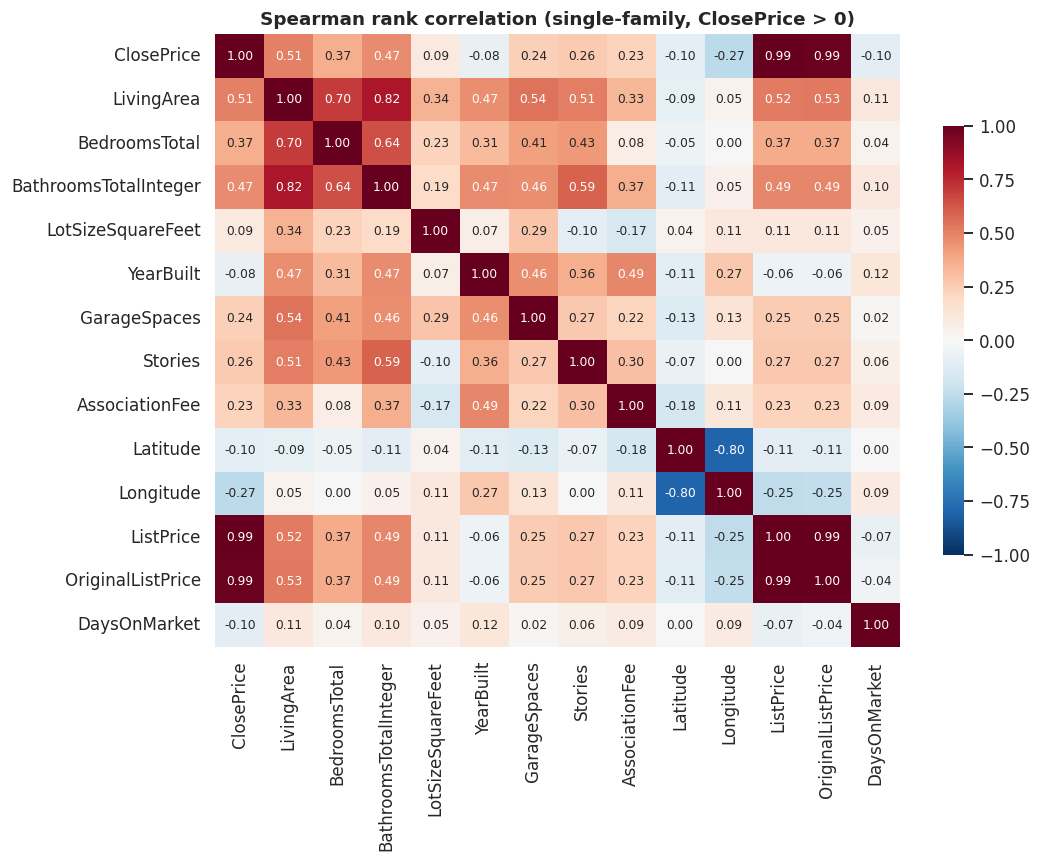

,spearman_vs_ClosePrice
ListPrice,0.99
OriginalListPrice,0.99
LivingArea,0.51
BathroomsTotalInteger,0.47
BedroomsTotal,0.37
Stories,0.26
GarageSpaces,0.24
AssociationFee,0.23
LotSizeSquareFeet,0.09
YearBuilt,-0.08


In [12]:
num = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt",
       "GarageSpaces", "Stories", "AssociationFee", "Latitude", "Longitude", "ListPrice", "OriginalListPrice", "DaysOnMarket"]
corr = df.loc[df.ClosePrice > 0, num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.7})
ax.set_title("Spearman rank correlation (single-family, ClosePrice > 0)")
plt.tight_layout(); save(fig, "correlation_heatmap"); plt.show()
corr["ClosePrice"].drop("ClosePrice").sort_values(ascending=False).to_frame("spearman_vs_ClosePrice")

`ListPrice` and `OriginalListPrice` correlate with `ClosePrice` at roughly 0.99. That is not a useful feature; it is the answer leaking in. Both are excluded from the model (best-practices section 04), along with `DaysOnMarket`. Among legitimate features, living area and bathrooms carry the strongest monotonic signal. Location (latitude/longitude) has a weak *linear rank* correlation but, as the next section shows, a very strong *spatial* effect that tree models and location features will capture.

## 8. Geography

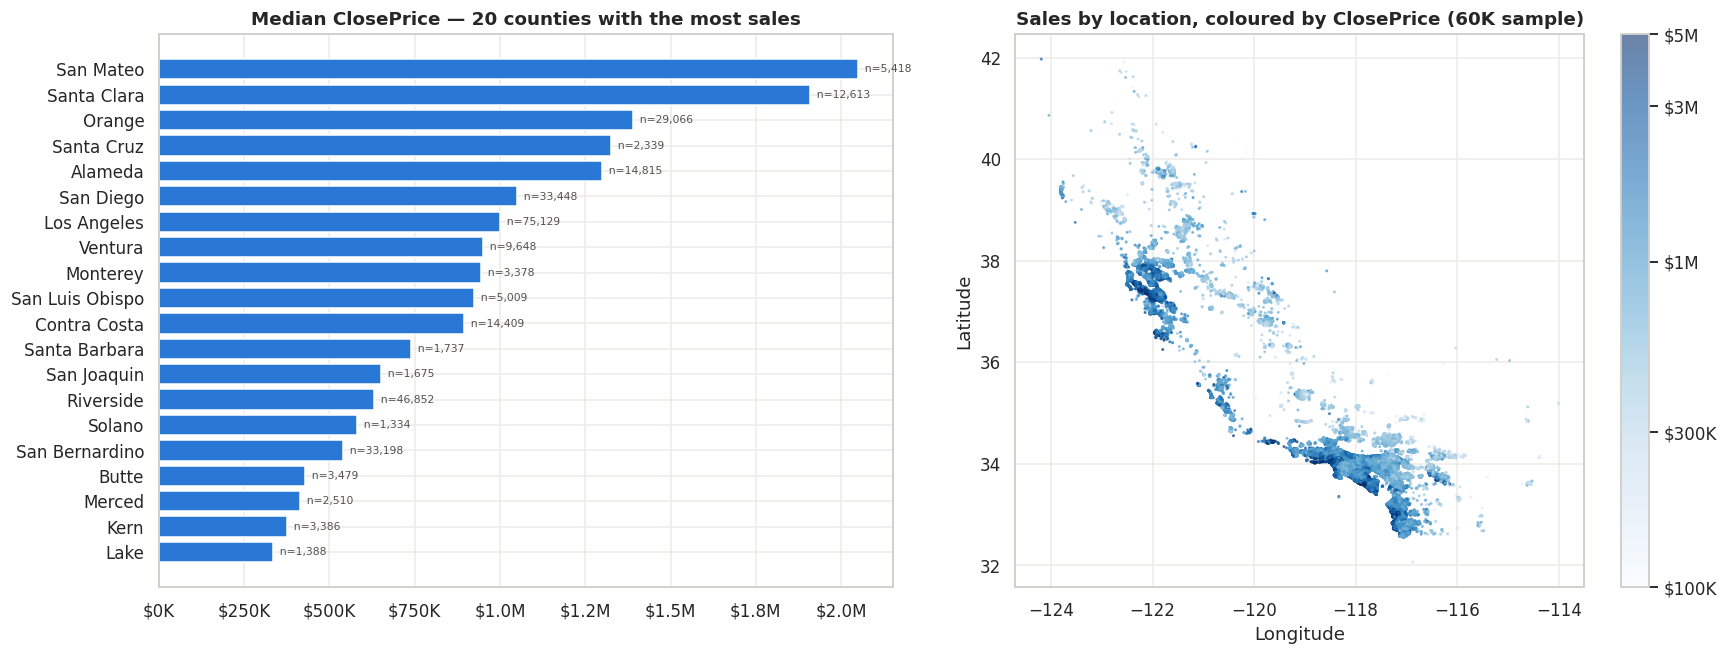

,sales,median_price,median_ppsf
CountyOrParish,,,
Los Angeles,75129,"999,000.00",631.58
Riverside,46852,"629,990.00",320.49
San Diego,33448,"1,050,000.00",598.52
San Bernardino,33198,"540,000.00",325.52
Orange,29066,"1,390,000.00",707.30
Alameda,14815,"1,300,000.00",752.38
Contra Costa,14409,"895,000.00",530.68
Santa Clara,12613,"1,910,000.00","1,104.22"
Ventura,9648,"950,000.00",532.92


In [13]:
top = df[df.ClosePrice > 0].groupby("CountyOrParish").agg(sales=("ClosePrice", "size"),
                                                         median_price=("ClosePrice", "median"))
top["median_ppsf"] = df[(df.ClosePrice > 0) & (df.LivingArea > 0)].assign(
    ppsf=lambda d: d.ClosePrice / d.LivingArea).groupby("CountyOrParish").ppsf.median()
top = top.sort_values("sales", ascending=False).head(20)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
t = top.sort_values("median_price")
ax[0].barh(t.index, t.median_price, color=BLUE); ax[0].xaxis.set_major_formatter(dollars)
ax[0].set_title("Median ClosePrice — 20 counties with the most sales")
for i, (v, n) in enumerate(zip(t.median_price, t.sales)):
    ax[0].text(v, i, f"  n={n:,}", va="center", fontsize=7, color="#52514e")

g = df[(df.ClosePrice > 0) & df.Latitude.between(32, 42.1) & df.Longitude.between(-124.5, -114)].sample(60000, random_state=42)
sc = ax[1].scatter(g.Longitude, g.Latitude, c=np.log10(g.ClosePrice.clip(1e5, 5e6)), s=1, cmap="Blues", alpha=0.6)
cb = plt.colorbar(sc, ax=ax[1]); cb.set_ticks(np.log10([1e5, 3e5, 1e6, 3e6, 5e6]))
cb.set_ticklabels(["$100K", "$300K", "$1M", "$3M", "$5M"])
ax[1].set_title("Sales by location, coloured by ClosePrice (60K sample)"); ax[1].set_aspect("equal")
ax[1].set_xlabel("Longitude"); ax[1].set_ylabel("Latitude")
plt.tight_layout(); save(fig, "geography"); plt.show()
top

In [14]:
# Coordinates: missing, zero, or outside California
bad_coord = df.Latitude.isna() | ~df.Latitude.between(32, 42.1) | ~df.Longitude.between(-124.5, -114)
print(f"Missing or out-of-California coordinates: {bad_coord.sum():,} ({bad_coord.mean():.2%})")
# latfilled / lonfilled are True/False flags (present only in the *_filled files) marking rows whose
# coordinates were back-filled (geocoded) rather than supplied by the MLS
filled = df[df.latfilled.notna()]
print("Files carrying latfilled/lonfilled:", sorted(filled.source_month.unique()))
print(f"Share of rows in those files with back-filled coordinates: {filled.latfilled.mean():.1%} "
      f"({int(filled.latfilled.sum()):,} rows)")
print("Back-filled rows still missing Latitude:", int((filled.latfilled & filled.Latitude.isna()).sum()))

Missing or out-of-California coordinates: 2,785 (0.90%)
Files carrying latfilled/lonfilled: ['202401', '202403', '202404', '202405', '202406', '202407', '202501']
Share of rows in those files with back-filled coordinates: 41.9% (33,810 rows)
Back-filled rows still missing Latitude: 0


## 9. Time trends

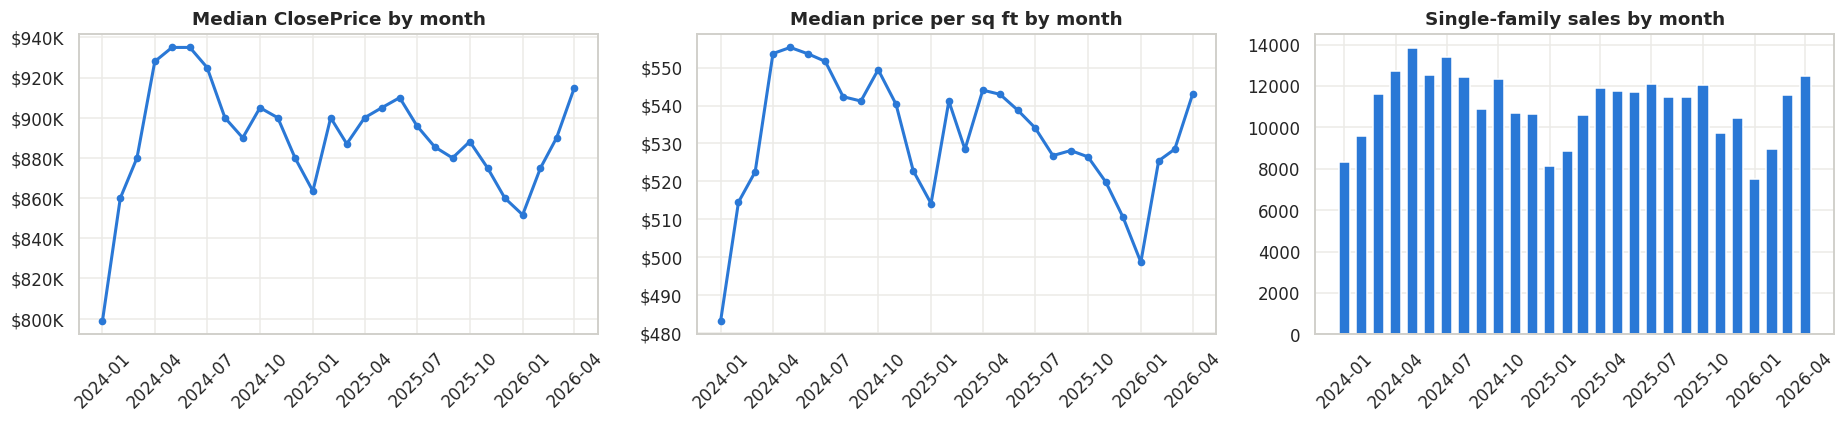

close_month,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01
sales,8322,9564,11634,12745,13831,12544,13378,12433,10909,12347,10692,10623,8144,8851,10610,11880,11777,11701,12113,11454,11456,12029,9739,10455,7490,8959,11562,12490
median_price,"$799,000","$860,000","$880,000","$928,000","$935,000","$935,000","$925,000","$900,000","$890,000","$905,000","$900,000","$880,000","$863,500","$900,000","$887,000","$900,000","$905,000","$910,000","$896,000","$885,500","$880,000","$888,163","$875,000","$860,000","$851,692","$875,000","$890,000","$915,000"
median_ppsf,$483,$515,$523,$554,$555,$554,$552,$542,$541,$549,$540,$523,$514,$541,$528,$544,$543,$539,$534,$527,$528,$526,$520,$511,$499,$525,$529,$543


In [15]:
m = df[df.ClosePrice > 0].groupby("close_month").agg(sales=("ClosePrice", "size"), median_price=("ClosePrice", "median"))
m["median_ppsf"] = df[(df.ClosePrice > 0) & (df.LivingArea > 0)].assign(
    ppsf=lambda d: d.ClosePrice / d.LivingArea).groupby("close_month").ppsf.median()
m.index = m.index.to_timestamp()

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(m.index, m.median_price, color=BLUE, lw=2, marker="o", ms=4); ax[0].yaxis.set_major_formatter(dollars)
ax[0].set_title("Median ClosePrice by month")
ax[1].plot(m.index, m.median_ppsf, color=BLUE, lw=2, marker="o", ms=4)
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}")); ax[1].set_title("Median price per sq ft by month")
ax[2].bar(m.index, m.sales, width=20, color=BLUE); ax[2].set_title("Single-family sales by month")
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); save(fig, "time_trends"); plt.show()
m.assign(median_price=m.median_price.map("${:,.0f}".format), median_ppsf=m.median_ppsf.map("${:,.0f}".format)).T

In [16]:
dfm = df[df.ClosePrice > 0].assign(month=df.CloseDate.dt.month)
seas = dfm.groupby("month").ClosePrice.median()
print("Median ClosePrice by calendar month (all years pooled):")
print(seas.map("${:,.0f}".format).to_string())

Median ClosePrice by calendar month (all years pooled):
month
1     $835,000
2     $878,500
3     $885,000
4     $915,000
5     $923,000
6     $925,000
7     $910,000
8     $895,000
9     $885,000
10    $900,000
11    $885,000
12    $869,450


## 10. Data-quality flags (to resolve in Week 3)

In [17]:
dates_ok = df.ListingContractDate.notna() & df.CloseDate.notna()
checks = {
    "ClosePrice <= 0 or missing": (df.ClosePrice.isna() | (df.ClosePrice <= 0)),
    "ClosePrice < $10,000": df.ClosePrice < 1e4,
    "ClosePrice > $20M": df.ClosePrice > 2e7,
    "LivingArea missing or 0": df.LivingArea.isna() | (df.LivingArea <= 0),
    "LivingArea < 300 sq ft": df.LivingArea.between(0.01, 299),
    "LivingArea > 15,000 sq ft": df.LivingArea > 15000,
    "BedroomsTotal == 0": df.BedroomsTotal == 0,
    "BedroomsTotal > 10": df.BedroomsTotal > 10,
    "BathroomsTotalInteger == 0": df.BathroomsTotalInteger == 0,
    "BathroomsTotalInteger > 10": df.BathroomsTotalInteger > 10,
    "Price per sq ft < $50 or > $3,000": ((df.ClosePrice / df.LivingArea) < 50) | ((df.ClosePrice / df.LivingArea) > 3000),
    "YearBuilt < 1850 or > close year": (df.YearBuilt < 1850) | (df.YearBuilt > df.CloseDate.dt.year + 1),
    "LotSizeSquareFeet == 0": df.LotSizeSquareFeet == 0,
    "CloseDate before ListingContractDate": dates_ok & (df.CloseDate < df.ListingContractDate),
    "CloseDate before PurchaseContractDate": df.CloseDate < df.PurchaseContractDate,
    "Missing/out-of-CA coordinates": df.Latitude.isna() | ~df.Latitude.between(32, 42.1) | ~df.Longitude.between(-124.5, -114),
    "Duplicate ListingKey": df.ListingKey.duplicated(keep="first"),
    "Duplicate address + CloseDate": df.duplicated(["UnparsedAddress", "PostalCode", "CloseDate"], keep="first"),
}
flags = pd.DataFrame({"rows": {k: int(v.sum()) for k, v in checks.items()}})
flags["pct_of_sfr"] = (flags.rows / len(df) * 100).round(3)
any_flag = np.logical_or.reduce([v.fillna(False).values for v in checks.values()])
print(f"Rows with at least one flag: {any_flag.sum():,} ({any_flag.mean():.2%})")
flags

Rows with at least one flag: 4,919 (1.59%)


,rows,pct_of_sfr
ClosePrice <= 0 or missing,3,0.00
"ClosePrice < $10,000",8,0.00
ClosePrice > $20M,207,0.07
LivingArea missing or 0,292,0.09
LivingArea < 300 sq ft,25,0.01
"LivingArea > 15,000 sq ft",48,0.01
BedroomsTotal == 0,176,0.06
BedroomsTotal > 10,48,0.01
BathroomsTotalInteger == 0,132,0.04
BathroomsTotalInteger > 10,179,0.06


In [18]:
# Duplicate ListingKeys: are they the same sale appearing in two monthly files?
d = df[df.ListingKey.duplicated(keep=False)].sort_values(["ListingKey", "CloseDate"])
print(f"{d.ListingKey.nunique()} ListingKeys appear more than once ({len(d)} rows)")
print("Same CloseDate and ClosePrice in every copy:",
      d.groupby("ListingKey").apply(lambda g: g.CloseDate.nunique() == 1 and g.ClosePrice.nunique() == 1,
                                    include_groups=False).mean().round(3))
d[["ListingKey", "source_month", "CloseDate", "ClosePrice", "UnparsedAddress", "City"]].head(8)

260 ListingKeys appear more than once (524 rows)
Same CloseDate and ClosePrice in every copy: 0.112


,ListingKey,source_month,CloseDate,ClosePrice,UnparsedAddress,City
68622,1031992525,202406,2024-06-21,"415,740.00",998 Shelbie Avenue,Brawley
117701,1031992525,202410,2024-10-18,"459,900.00",998 Shelbie Avenue,Brawley
56024,1037464932,202405,2024-05-25,"650,000.00",13448 Park Street,Whittier
105345,1037464932,202409,2024-09-06,"665,000.00",13448 Park Street,Whittier
68372,1046689006,202406,2024-06-30,"825,000.00",209 Atlantic City Avenue,Grover Beach
117650,1046689006,202410,2024-10-29,"825,000.00",209 Atlantic City Avenue,Grover Beach
68280,1048638478,202406,2024-06-25,"6,600,000.00",23649 Long Valley Road,Hidden Hills
94313,1048638478,202408,2024-08-21,"6,550,000.00",23649 Long Valley Road,Hidden Hills


## 11. Sale-to-list ratio (context only, not a model feature)

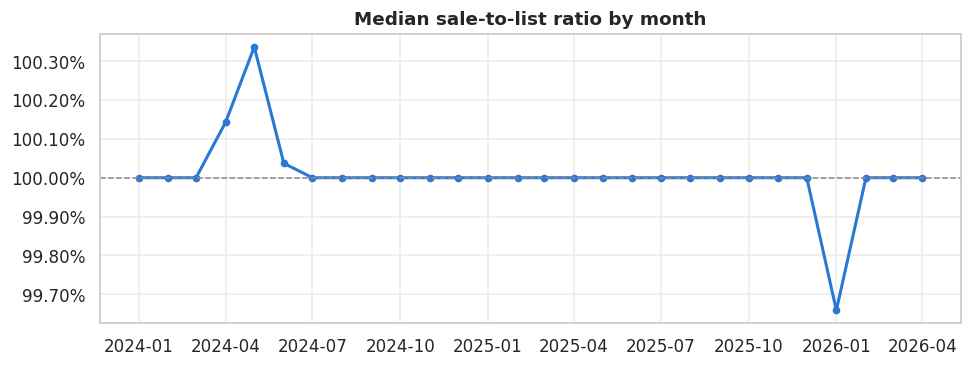

Share of sales closing above list price: 42.5%


In [19]:
r = (df.ClosePrice / df.ListPrice).replace([np.inf, -np.inf], np.nan)
r = r[r.between(0.5, 1.5)]
mr = r.groupby(df.loc[r.index, "close_month"]).median()
mr.index = mr.index.to_timestamp()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(mr.index, mr.values, color=BLUE, lw=2, marker="o", ms=4)
ax.axhline(1, color=GREY, ls="--", lw=1); ax.set_title("Median sale-to-list ratio by month")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); save(fig, "sale_to_list"); plt.show()
print(f"Share of sales closing above list price: {(r > 1).mean():.1%}")

In [20]:
# Snapshot of what was analysed, for reproducibility
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)
print("Files:", ", ".join(f.name for f in files))

pandas 2.3.3 | numpy 2.2.6 | seaborn 0.13.2
Files: CRMLSSold202401_filled.csv, CRMLSSold202402.csv, CRMLSSold202403_filled.csv, CRMLSSold202404_filled.csv, CRMLSSold202405_filled.csv, CRMLSSold202406_filled.csv, CRMLSSold202407_filled.csv, CRMLSSold202408.csv, CRMLSSold202409.csv, CRMLSSold202410.csv, CRMLSSold202411.csv, CRMLSSold202412.csv, CRMLSSold202501_filled.csv, CRMLSSold202502.csv, CRMLSSold202503.csv, CRMLSSold202504.csv, CRMLSSold202505.csv, CRMLSSold202506.csv, CRMLSSold202507.csv, CRMLSSold202508.csv, CRMLSSold202509.csv, CRMLSSold202510.csv, CRMLSSold202511.csv, CRMLSSold202512.csv, CRMLSSold202601.csv, CRMLSSold202602.csv, CRMLSSold202603.csv, CRMLSSold202604.csv


## 12. Key findings and hand-off to Week 3

**Data volume.** 28 monthly sold files (January 2024 – April 2026), 615,707 closed records, of which **309,735 (50.3%) are single-family residences**. Monthly single-family volume runs from about 7,500 (January 2026) to about 13,800 (May 2024), comfortably above the six-month minimum. The most recent complete month, **April 2026 (12,490 sales)**, is the natural test month.

**Target.** `ClosePrice` is extremely right-skewed (skewness about 132; median \$894K, mean \$1.30M). On a log scale it is roughly normal (skewness 0.48). The 0.5th / 99.5th percentiles across all months are about \$190K and \$8.5M; these will be recomputed on the training window only. There is 1 zero price, 2 missing prices, 8 sales under \$10K and 207 over \$20M (maximum \$989.5M, which is clearly a data-entry error).

**Core features.** Typical home: about 1,800 sq ft, 3 bedrooms, 2 bathrooms, a 7,245 sq ft lot, built in 1976. Living area (Spearman 0.51) and bathrooms (0.47) carry the strongest monotonic signal, then bedrooms (0.37). Lot size is weak on its own (0.09) and very heavy-tailed. Living area, bedrooms and bathrooms are themselves strongly correlated (0.64–0.82), which matters for the linear baseline.

**Location dominates.** County medians range from about \$335K (Lake) to \$2.05M (San Mateo), a six-fold spread that dwarfs any single physical feature. Price per square foot ranges from about \$220 to \$1,180 by county. Location features (county, ZIP, coordinates, and the Week 6 school-district join) will be essential.

**Time.** Median price climbed from \$799K (January 2024) to a \$935K peak (May–June 2024), drifted down to about \$852K (January 2026), and recovered to \$915K by April 2026. There is a clear spring/summer seasonal lift of roughly 10% over winter. A month-of-year feature (sine/cosine) and care in choosing the training window X are both justified.

**Leakage confirmed.** `ListPrice` and `OriginalListPrice` have a 0.99 rank correlation with `ClosePrice`; they are excluded, as are `DaysOnMarket` and the close/contract dates as predictors. About 42.5% of sales closed above list price.

**Missingness.** Nine columns are completely empty for single-family homes (including `TaxAnnualAmount`, `ElementarySchoolDistrict`, `FireplacesTotal`). Twenty more are over 50% missing. The core modelling fields (`LivingArea`, beds, baths, `YearBuilt`, coordinates, lot size) are all at or below 2% missing.

**Data-quality items for `02_preprocessing.ipynb`:**
1. Drop the 3 rows with missing or zero `ClosePrice`.
2. Remove or impute 292 rows with missing/zero `LivingArea`; review 0-bedroom (176) and 0-bathroom (132) homes and the implausible extremes (up to 45 beds, 175 baths, 123,764 sq ft).
3. Apply a price-per-square-foot sanity filter (769 rows fall outside \$50–\$3,000).
4. Use `LotSizeSquareFeet` (agrees with `LotSizeAcres` 99.9% of the time); do not use `LotSizeArea`, which mixes square feet and acres.
5. 260 `ListingKey`s appear in two monthly files, usually with a different close date and price (re-sales or corrected records). Keep the latest record per key and log the count.
6. 2,785 rows (0.9%) have missing or out-of-California coordinates. In the seven `_filled` files, 41.9% of coordinates were back-filled (`latfilled == True`); keep that flag as a possible quality indicator.
7. 44 rows close before their listing date and 196 before their purchase-contract date; drop them as logical impossibilities.
8. Convert the True/False flag columns (`PoolPrivateYN`, `ViewYN`, etc.) and add missing-indicator flags where missingness may carry meaning (`AssociationFee`, `Stories`).

Overall, only about 1.6% of single-family rows trip any quality flag, so cleaning will cost little data.